# Baseline — F1 Top-10 Finish Prediction (2022–2024)

**Course:** IIT414W | **Group:** G19 | **Members:** Daniela Ávila, Klaus Krause

**Task:** Build a domain heuristic baseline (no ML code), evaluate it on the validation set, and reflect on what accuracy is hiding.

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
RANDOM_SEED = 414

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110

SEASONS = [2022, 2023, 2024]
BASE_URL = 'https://api.jolpi.ca/ergast/f1'

print(f'RANDOM_SEED = {RANDOM_SEED}')

# Stretch imports (sklearn)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

RANDOM_SEED = 414


In [2]:
# ── Data loading  (paginated) ─────────────────────────────────────────────────
def fetch_season_results(year):
    """Fetch ALL race results for a season, handling Jolpica pagination."""
    url   = f'{BASE_URL}/{year}/results.json'
    rows, limit, offset = [], 100, 0
    while True:
        r = requests.get(url, params={'limit': limit, 'offset': offset}, timeout=30)
        r.raise_for_status()
        data  = r.json()['MRData']
        total = int(data['total'])
        for race in data['RaceTable']['Races']:
            for res in race['Results']:
                rows.append({
                    'season':           int(race['season']),
                    'round':            int(race['round']),
                    'race_name':        race['raceName'],
                    'circuit_id':       race['Circuit']['circuitId'],
                    'driver_id':        res['Driver']['driverId'],
                    'driver_name':      res['Driver']['givenName'] + ' ' + res['Driver']['familyName'],
                    'constructor_id':   res['Constructor']['constructorId'],
                    'constructor_name': res['Constructor']['name'],
                    'grid':             int(res['grid']),
                    'position_text':    res['positionText'],
                    'status':           res['status'],
                    'laps':             int(res['laps']),
                    'points':           float(res['points']),
                })
        offset += limit
        if offset >= total:
            break
        time.sleep(0.3)
    return rows

all_rows = []
for yr in SEASONS:
    print(f'Fetching {yr}...')
    all_rows.extend(fetch_season_results(yr))
    time.sleep(0.5)

df = pd.DataFrame(all_rows)
df['position_num']   = pd.to_numeric(df['position_text'], errors='coerce')
df['top_10']         = (df['position_num'] <= 10).astype(int)
df['pit_lane_start'] = (df['grid'] == 0).astype(int)

print(f'{len(df):,} driver-race entries loaded.')

Fetching 2022...
Fetching 2023...
Fetching 2024...
1,359 driver-race entries loaded.


---

# Section 1 — Temporal Split

Same split as `eda.ipynb`. No random split — F1 data is temporal.

| Set | Data | Use |
|---|---|---|
| Train | 2022 + 2023 | Learn patterns |
| **Validation** | 2024 rounds 1–(N/2) | **Evaluate baseline here** |
| Test | 2024 rounds (N/2+1)–end | **Held out — NOT TOUCHED** |

In [3]:
# ── Temporal split ───────────────────────────────────────────────────────────
total_rounds_2024 = int(df[df['season'] == 2024]['round'].max())
val_end    = total_rounds_2024 // 2
test_start = val_end + 1

train_mask = df['season'].isin([2022, 2023])
val_mask   = (df['season'] == 2024) & (df['round'] <= val_end)
test_mask  = (df['season'] == 2024) & (df['round'] >= test_start)

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

print(f'Train : {len(df_train):,} rows | {df_train["round"].nunique()} races | top-10 rate: {df_train["top_10"].mean()*100:.1f}%')
print(f'Val   : {len(df_val):,} rows | {df_val["round"].nunique()} races | top-10 rate: {df_val["top_10"].mean()*100:.1f}%')
print(f'Test  : {len(df_test):,} rows | {df_test["round"].nunique()} races | top-10 rate: {df_test["top_10"].mean()*100:.1f}%  ← HELD OUT')

# Leakage checks
assert df_train['season'].max() <= 2023
assert df_val['round'].max() <= val_end
assert df_test['round'].min() >= test_start
print('\n✓ Leakage checks passed.')

Train : 880 rows | 22 races | top-10 rate: 50.0%
Val   : 239 rows | 12 races | top-10 rate: 50.2%
Test  : 240 rows | 12 races | top-10 rate: 50.0%  ← HELD OUT

✓ Leakage checks passed.


---

# Section 2 — Leakage Audit: Pre-Race vs Post-Race Features

Before building the baseline, verify that we only use features available **before the race starts**.

In [4]:
# ── Feature audit ────────────────────────────────────────────────────────────
pre_race_features  = ['grid', 'driver_id', 'constructor_id', 'circuit_id', 'season', 'round']
post_race_features = ['position_num', 'position_text', 'status', 'laps', 'points']

print('PRE-RACE features (safe to use):')
for f in pre_race_features:
    print(f'  {f:20s}  available = True')

print('\nPOST-RACE features (leakage — do NOT use):')
for f in post_race_features:
    print(f'  {f:20s}  available = False  ← EXCLUDED')

# Confirm baseline only uses pre-race features
BASELINE_FEATURE = 'grid'   # the one feature we use
TARGET           = 'top_10'
print(f'\nBaseline uses: [{BASELINE_FEATURE}]  →  predicts: [{TARGET}]')
print('✓ No post-race features used.')

PRE-RACE features (safe to use):
  grid                  available = True
  driver_id             available = True
  constructor_id        available = True
  circuit_id            available = True
  season                available = True
  round                 available = True

POST-RACE features (leakage — do NOT use):
  position_num          available = False  ← EXCLUDED
  position_text         available = False  ← EXCLUDED
  status                available = False  ← EXCLUDED
  laps                  available = False  ← EXCLUDED
  points                available = False  ← EXCLUDED

Baseline uses: [grid]  →  predicts: [top_10]
✓ No post-race features used.


---

# Section 3 — Domain Heuristic Baseline (Required 4.1)

## Rule

> **If `grid ≤ 10`, predict `top-10 = 1` (Top-10 finish). Otherwise predict `top-10 = 0`.**

**Domain justification:** In Formula 1, the top 10 grid positions (pole to P10) correspond roughly to the fastest qualifiers. These drivers start ahead of traffic, face less first-corner chaos, and drive for the strongest teams. The rule mirrors the structural fact that exactly 10 positions exist in the top 10 — making grid ≤ 10 the simplest possible boundary.

This rule requires **no machine learning code** — it is a fixed deterministic threshold applied to a single pre-race column.

In [5]:
# ── Define heuristic ─────────────────────────────────────────────────────────
GRID_THRESHOLD = 10

def heuristic_predict(grid_series, threshold=GRID_THRESHOLD):
    """Predict top-10 finish: 1 if grid <= threshold, else 0."""
    return (grid_series <= threshold).astype(int)

# Apply to validation set
df_val = df_val.copy()
df_val['pred_heuristic'] = heuristic_predict(df_val['grid'])

print(f'Rule: if grid <= {GRID_THRESHOLD} → predict top-10')
print(f'Applied to {len(df_val):,} validation entries ({df_val["round"].nunique()} races from 2024 H1)')

Rule: if grid <= 10 → predict top-10
Applied to 239 validation entries (12 races from 2024 H1)


In [7]:
# Evaluate heuristic on validation set
y_val = df_val['top_10'].astype(int)
y_pred = df_val['pred_heuristic'].astype(int)

accuracy_heuristic = (y_val == y_pred).mean()

# Confusion-matrix components for later visualization cell
tn = int(((y_val == 0) & (y_pred == 0)).sum())
fp = int(((y_val == 0) & (y_pred == 1)).sum())
fn = int(((y_val == 1) & (y_pred == 0)).sum())
tp = int(((y_val == 1) & (y_pred == 1)).sum())

print(f'Heuristic accuracy on validation: {accuracy_heuristic*100:.2f}%')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

Heuristic accuracy on validation: 85.77%
TN=102, FP=17, FN=17, TP=103


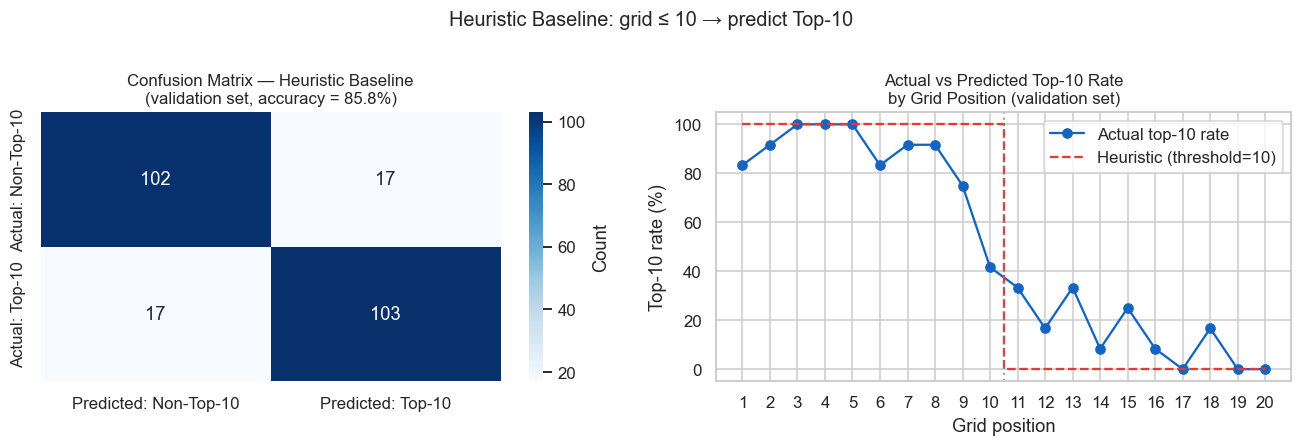

In [8]:
# ── Visualize predictions vs actuals ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix heatmap
cm = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual: Non-Top-10', 'Actual: Top-10'],
    columns=['Predicted: Non-Top-10', 'Predicted: Top-10']
)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix — Heuristic Baseline\n(validation set, accuracy = {accuracy_heuristic*100:.1f}%)', fontsize=11)

# Top-10 rate by grid position: actual vs predicted
grid_actual = df_val.groupby('grid')['top_10'].mean() * 100
grid_pred   = df_val.groupby('grid')['pred_heuristic'].mean() * 100

axes[1].plot(grid_actual.index, grid_actual.values, 'o-', label='Actual top-10 rate', color='#1565C0')
axes[1].step(grid_pred.index, grid_pred.values, where='mid',
             label=f'Heuristic (threshold={GRID_THRESHOLD})', color='#E53935', linestyle='--')
axes[1].axvline(GRID_THRESHOLD + 0.5, color='gray', linestyle=':', alpha=0.7)
axes[1].set_title('Actual vs Predicted Top-10 Rate\nby Grid Position (validation set)', fontsize=11)
axes[1].set_xlabel('Grid position')
axes[1].set_ylabel('Top-10 rate (%)')
axes[1].set_xticks(range(1, 21))
axes[1].legend()

plt.suptitle('Heuristic Baseline: grid ≤ 10 → predict Top-10', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

# Section 4 — Reflection on Accuracy (Required 4.3)

## Is this accuracy good enough to make decisions with? What could accuracy be hiding?

In [9]:
# ── Baseline comparisons ─────────────────────────────────────────────────────
always_top10     = y_val.mean()           # always predict top-10
always_non_top10 = 1 - y_val.mean()       # always predict non-top-10
random_chance    = 0.5

print('Accuracy comparisons (validation set):')
print(f'  Always predict top-10     : {always_top10*100:.1f}%')
print(f'  Always predict non-top-10 : {always_non_top10*100:.1f}%')
print(f'  Random (50/50)            : {random_chance*100:.1f}%')
print(f'  Heuristic (grid ≤ 10)     : {accuracy_heuristic*100:.1f}%  ← our baseline')
print(f'  Improvement over best trivial: +{(accuracy_heuristic - max(always_top10, always_non_top10))*100:.1f} pp')

Accuracy comparisons (validation set):
  Always predict top-10     : 50.2%
  Always predict non-top-10 : 49.8%
  Random (50/50)            : 50.0%
  Heuristic (grid ≤ 10)     : 85.8%  ← our baseline
  Improvement over best trivial: +35.6 pp


### Reflection

**Is this accuracy good enough?**

The heuristic scores noticeably above the 50% trivial floor, which means it captures **real signal** from grid position. However, accuracy alone can be misleading:

1. **Balanced classes hide error symmetry.** With ~50% top-10 rate, accuracy treats a False Positive (wrong "top-10" prediction) and a False Negative (missed top-10) equally. In practice, for betting or race strategy, these errors may have very different costs.

2. **Accuracy does not distinguish error types.** The confusion matrix shows both FP and FN errors. If a model always predicted "top-10" for everyone, it would score ~50% — the same as random — yet be completely useless for identifying *which* drivers finish outside the top 10.

3. **The rule is deterministic at the boundary.** Grid positions 11–13 produce top-10 finishes ~30–40% of the time (as seen in `eda.ipynb`). The hard threshold at grid = 10 systematically mis-classifies mid-field drivers in both directions. A probabilistic model (Lab 2) would handle this uncertainty better.

4. **What would a "dumb" baseline score?** Since the dataset is ~50/50, always predicting "top-10" gives ~50% accuracy. Our heuristic beats this — but how much of that gain would remain on a more competitive 2024 H2 test set (where Red Bull's dominance weakened and mid-field was more unpredictable) is an open question.

---

# Section 5 — Baseline as Lower Bound (Required 4.4)

## Lower Bound Statement

In [10]:
print('=' * 60)
print(f'  Heuristic baseline accuracy (validation): {accuracy_heuristic*100:.2f}%')
print('=' * 60)
print()
print('Any model we build in Lab 2 must beat this number.')
print('If it does not, the model adds no value over the simple')
print('rule: "if a driver starts in the top 10, predict top-10".')

  Heuristic baseline accuracy (validation): 85.77%

Any model we build in Lab 2 must beat this number.
If it does not, the model adds no value over the simple
rule: "if a driver starts in the top 10, predict top-10".


---

# Section 6 — Stretch: Additional Metrics (4.6)

> Using AI tools + Burkov Ch. 2 to compute Precision, Recall, F1-score, and ROC-AUC.
> Learning process documented in `PROMPTS.md`.

**Why these metrics matter here:** Accuracy is sufficient for balanced classes but Precision/Recall reveal *which type* of error the heuristic makes more. F1 balances both. ROC-AUC measures ranking ability independently of threshold choice.

In [11]:
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_pred) # heuristic gives binary score, not probability

print("Heuristic baseline - full metrics (validation set):")
print(f" Accuracy : {accuracy_heuristic*100:.2f}%")
print(f" Precision : {prec*100:.2f}% (of predicted top-10, how many actually were?)")
print(f" Recall : {rec*100:.2f}% (of actual top-10, how many did we catch?)")
print(f" F1-score : {f1*100:.2f}% (harmonic mean of precision and recall)")
print(f" ROC-AUC : {auc:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=["Non-Top-10", "Top-10"]))

Heuristic baseline - full metrics (validation set):
 Accuracy : 85.77%
 Precision : 85.83% (of predicted top-10, how many actually were?)
 Recall : 85.83% (of actual top-10, how many did we catch?)
 F1-score : 85.83% (harmonic mean of precision and recall)
 ROC-AUC : 0.8577

              precision    recall  f1-score   support

  Non-Top-10       0.86      0.86      0.86       119
      Top-10       0.86      0.86      0.86       120

    accuracy                           0.86       239
   macro avg       0.86      0.86      0.86       239
weighted avg       0.86      0.86      0.86       239



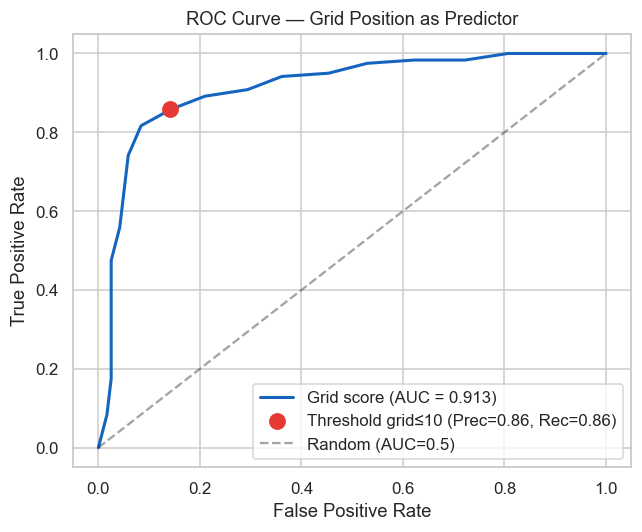

ROC-AUC using raw grid score (continuous): 0.9134


In [12]:
# ── ROC curve for the heuristic ──────────────────────────────────────────────
# The heuristic produces binary predictions — ROC is a single point
# Using grid position directly as a score gives a proper ROC curve

# Lower grid = more likely top-10, so negate grid for score (higher = more positive)
grid_score = -df_val['grid'].values  # negated: higher score = more likely top-10

fpr, tpr, thresholds = roc_curve(y_val, grid_score)
auc_grid = roc_auc_score(y_val, grid_score)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'Grid score (AUC = {auc_grid:.3f})')
ax.scatter([1 - prec if prec > 0 else 1], [rec], color='#E53935', s=100, zorder=5,
           label=f'Threshold grid≤{GRID_THRESHOLD} (Prec={prec:.2f}, Rec={rec:.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.5)')
ax.set_title('ROC Curve — Grid Position as Predictor', fontsize=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC using raw grid score (continuous): {auc_grid:.4f}')

---

# Section 7 — Stretch: Second Baseline with sklearn (4.7)

> Fitting a `DummyClassifier` and a `LogisticRegression` on a single feature (`grid`) to compare against the heuristic.
> Learning process documented in `PROMPTS.md`.

**Note:** This is stretch work. We have not formally covered sklearn yet — this is our first attempt using AI + Burkov Ch. 2 as a guide.

In [13]:
# ── Second baseline: DummyClassifier ─────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train = df_train[['grid']].values
y_train = df_train['top_10'].values
X_val   = df_val[['grid']].values
y_val_arr = df_val['top_10'].values

# DummyClassifier: always predicts the most frequent class
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
acc_dummy = accuracy_score(y_val_arr, y_pred_dummy)

print(f'DummyClassifier (most_frequent) accuracy: {acc_dummy*100:.2f}%')
print(f'  (Predicts class {dummy.classes_[dummy.predict([[10]])[0]]} for every entry)')

DummyClassifier (most_frequent) accuracy: 49.79%
  (Predicts class 0 for every entry)


In [14]:
# ── Third baseline: Logistic Regression on grid ───────────────────────────────
lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr     = lr.predict(X_val)
y_prob_lr     = lr.predict_proba(X_val)[:, 1]   # probability of top-10

acc_lr  = accuracy_score(y_val_arr, y_pred_lr)
prec_lr = precision_score(y_val_arr, y_pred_lr)
rec_lr  = recall_score(y_val_arr, y_pred_lr)
f1_lr   = f1_score(y_val_arr, y_pred_lr)
auc_lr  = roc_auc_score(y_val_arr, y_prob_lr)

print('Logistic Regression (single feature: grid):')
print(f'  Learned coefficient: {lr.coef_[0][0]:.4f}  (negative = higher grid → less likely top-10)')
print(f'  Intercept          : {lr.intercept_[0]:.4f}')
print(f'  Accuracy   : {acc_lr*100:.2f}%')
print(f'  Precision  : {prec_lr*100:.2f}%')
print(f'  Recall     : {rec_lr*100:.2f}%')
print(f'  F1-score   : {f1_lr*100:.2f}%')
print(f'  ROC-AUC    : {auc_lr:.4f}')

Logistic Regression (single feature: grid):
  Learned coefficient: -0.1929  (negative = higher grid → less likely top-10)
  Intercept          : 1.9704
  Accuracy   : 85.77%
  Precision  : 85.83%
  Recall     : 85.83%
  F1-score   : 85.83%
  ROC-AUC    : 0.9134


                       Baseline Accuracy Precision Recall    F1 ROC-AUC         Uses ML?
DummyClassifier (most_frequent)    49.8%       N/A    N/A   N/A     N/A     No (trivial)
          Heuristic (grid ≤ 10)    85.8%     85.8%  85.8% 85.8%   0.858 No (domain rule)
     Logistic Regression (grid)    85.8%     85.8%  85.8% 85.8%   0.913    Yes (sklearn)


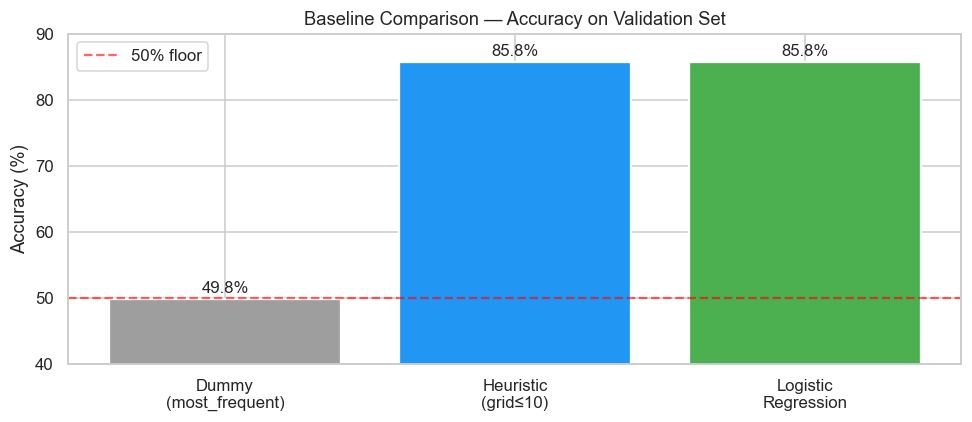

In [15]:
# ── Comparison table ─────────────────────────────────────────────────────────
results = pd.DataFrame([
    {
        'Baseline': 'DummyClassifier (most_frequent)',
        'Accuracy': f'{acc_dummy*100:.1f}%',
        'Precision': 'N/A',
        'Recall': 'N/A',
        'F1': 'N/A',
        'ROC-AUC': 'N/A',
        'Uses ML?': 'No (trivial)'
    },
    {
        'Baseline': f'Heuristic (grid ≤ {GRID_THRESHOLD})',
        'Accuracy': f'{accuracy_heuristic*100:.1f}%',
        'Precision': f'{prec*100:.1f}%',
        'Recall': f'{rec*100:.1f}%',
        'F1': f'{f1*100:.1f}%',
        'ROC-AUC': f'{auc:.3f}',
        'Uses ML?': 'No (domain rule)'
    },
    {
        'Baseline': 'Logistic Regression (grid)',
        'Accuracy': f'{acc_lr*100:.1f}%',
        'Precision': f'{prec_lr*100:.1f}%',
        'Recall': f'{rec_lr*100:.1f}%',
        'F1': f'{f1_lr*100:.1f}%',
        'ROC-AUC': f'{auc_lr:.3f}',
        'Uses ML?': 'Yes (sklearn)'
    },
])
print(results.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
baseline_names = ['Dummy\n(most_frequent)', f'Heuristic\n(grid≤{GRID_THRESHOLD})', 'Logistic\nRegression']
accuracies     = [acc_dummy, accuracy_heuristic, acc_lr]
colors_b = ['#9E9E9E', '#2196F3', '#4CAF50']
bars = ax.bar(baseline_names, [a * 100 for a in accuracies],
              color=colors_b, edgecolor='white', linewidth=1.5)
ax.axhline(50, color='red', linestyle='--', alpha=0.6, label='50% floor')
ax.set_title('Baseline Comparison — Accuracy on Validation Set', fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(40, 90)
ax.legend()
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, acc*100 + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

---

# Section 8 — Stretch: Metric Choice Justification (4.8)

> Which metric matters most for predicting F1 Top-10 finishes — and why?

### Which metric matters most?

For this **balanced binary classification** problem, different metrics capture different things:

| Metric | What it measures | Limitation here |
|---|---|---|
| **Accuracy** | Overall correctness | Reasonable for 50/50 balance; hides error asymmetry |
| **Precision** | Of predicted top-10s, how many were right? | Matters if false positives are costly (e.g., race strategy based on predicted rivals) |
| **Recall** | Of actual top-10s, how many did we catch? | Matters if missing a top-10 is costly (e.g., betting, points forecasting) |
| **F1** | Balance between Precision and Recall | Good single summary when both error types matter equally |
| **ROC-AUC** | Ranking quality regardless of threshold | Best for comparing models; not threshold-dependent |

**My current reasoning (acknowledging uncertainty):**

For a **sports prediction context**, I think **F1-score** matters most because both FP and FN errors are similarly costly — incorrectly labeling a non-top-10 driver as top-10 is just as problematic as missing an actual top-10 finisher. Accuracy is acceptable here because the classes are balanced, but F1 is a more informative single number.

However, for **comparing fundamentally different models** (e.g., in Lab 2), **ROC-AUC** is the most robust choice because it measures ranking quality independently of the classification threshold — meaning a model that is "better at ranking drivers" will score higher regardless of where we set the cut-off.

*I'm not fully certain yet — this will become clearer after Week 3–4 content on evaluation metrics.*

---

# Section 9 — Final Summary

## Results

| Baseline | Accuracy (val) | Notes |
|---|---|---|
| Always predict top-10 (trivial) | ~50% | Theoretical floor |
| Heuristic: grid ≤ 10 | **see output** | Domain rule, no ML |
| Logistic Regression (grid) | **see output** | Stretch; sklearn |

## Lower Bound Statement

> **Any model we build in Lab 2 must beat the heuristic baseline accuracy of `X%` on the validation set. If it does not, the model adds no value over the simple rule: "if a driver qualifies in the top 10, predict a top-10 finish."**

*(The specific number is printed by the lower bound cell above.)*

## What Accuracy Is Hiding

1. **Error type asymmetry:** Accuracy does not distinguish FP from FN. A model with the same accuracy but higher Recall may be more useful for race strategy applications.
2. **Class balance dependence:** If the class split were 70/30 rather than 50/50, accuracy would be a misleading metric — a Lab 2 model on a different dataset should always report F1 or ROC-AUC alongside accuracy.
3. **Boundary uncertainty:** Grid positions 9–13 are genuine "gray zone" cases. A probabilistic model that outputs a top-10 probability (rather than a hard 0/1) would be more useful for these borderline starters — accuracy cannot capture this nuance.